#  CNN Predection
Loaded The Liberaries

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout

from tensorflow.keras.utils import to_categorical

# Ye asli CNN banane ke building blocks hain — inhi se model architecture banega.

# Loaded The Data

In [3]:
import tensorflow as tf

data_dir = "flowers"   # or use the full path: r"C:\Deep_Learning\CNN\flowers"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred", # folder ka naam hi label ban jayega
    image_size=(224, 224), # Har image ko resize kar ke 224x224 pixels ka bana diya jayega
    batch_size=32, # ek baar mai model ko 32 images ka group diya jayega 
    validation_split=0.2, # total data ka 80% training ke liyea rakha jayega aur 20% validation ke liyea
    subset="training", 
    seed=42 #random Splitting hamesha seed ke saath chiyea taki har baar same split mile
)

val_ds = tf.keras.utils.image_dataset_from_directory( # sabkuch same bas remaning 20% validation data ke liyea
    data_dir,
    labels="inferred",
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

class_names = train_ds.class_names # Ye folder name ko ek list mai nikaal leta hai
print(class_names)

'''
Important: Ye list ka order hi model ke output se match karega. Yani agar model output index 0 de, to matlab "daisy", index 2 de to matlab "rose" — isi list ke through hum number ko naam mein convert karenge (prediction step mein yahi use hoga).
'''

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


'\nImportant: Ye list ka order hi model ke output se match karega. Yani agar model output index 0 de, to matlab "daisy", index 2 de to matlab "rose" — isi list ke through hum number ko naam mein convert karenge (prediction step mein yahi use hoga).\n'

# Normalization
#Images ki pixel values 0-255 range mein hoti hain, unko 0-1 mein scale karna hota hai:

In [4]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

'''
Images ke pixel values 0 se 255 tak hote hain (RGB colors). 
Neural networks bade numbers ke saath achhe se train nahi hote — 
isliye har pixel ko 255 se divide karke 0 se 1 ke range mein le aate hain. .map() ka matlab hai: 
dataset ke har image (x) pe ye rescaling apply karo, label (y) ko waise hi rehne do.
'''

'\nImages ke pixel values 0 se 255 tak hote hain (RGB colors). \nNeural networks bade numbers ke saath achhe se train nahi hote — \nisliye har pixel ko 255 se divide karke 0 se 1 ke range mein le aate hain. .map() ka matlab hai: \ndataset ke har image (x) pe ye rescaling apply karo, label (y) ko waise hi rehne do.\n'

In [5]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

'''

Ye sirf speed optimization hai:

cache() → ek baar disk se padh liya, RAM mein rakh liya (baar baar disk access nahi karna padega)
shuffle(1000) → data ko mix kar diya taaki model order yaad na kar le
prefetch() → agla batch tayyar rakhta hai jab tak current batch train ho raha hai (GPU/CPU idle na baithe)

'''

'\n\nYe sirf speed optimization hai:\n\ncache() → ek baar disk se padh liya, RAM mein rakh liya (baar baar disk access nahi karna padega)\nshuffle(1000) → data ko mix kar diya taaki model order yaad na kar le\nprefetch() → agla batch tayyar rakhta hai jab tak current batch train ho raha hai (GPU/CPU idle na baithe)\n\n'

In [6]:
val_ds = val_ds.map(lambda x, y: (normalization_layer(x),y))

'''

Ye sirf speed optimization hai:

cache() → ek baar disk se padh liya, RAM mein rakh liya (baar baar disk access nahi karna padega)
shuffle(1000) → data ko mix kar diya taaki model order yaad na kar le
prefetch() → agla batch tayyar rakhta hai jab tak current batch train ho raha hai (GPU/CPU idle na baithe)

'''

'\n\nYe sirf speed optimization hai:\n\ncache() → ek baar disk se padh liya, RAM mein rakh liya (baar baar disk access nahi karna padega)\nshuffle(1000) → data ko mix kar diya taaki model order yaad na kar le\nprefetch() → agla batch tayyar rakhta hai jab tak current batch train ho raha hai (GPU/CPU idle na baithe)\n\n'

In [7]:
AUTOTUNE = tf.data.AUTOTUNE
''' 
tf.data.AUTOTUNE = TensorFlow को बोलना कि "तुम खुद decide करो कि कितनी parallelism चाहिए"

इससे data loading और preprocessing तेज़ हो जाती है।

CNN training में जब आप dataset.map(..., num_parallel_calls=tf.data.AUTOTUNE) लिखते हो, तो TensorFlow automatically best number of parallel calls चुन लेता है।
'''

' \ntf.data.AUTOTUNE = TensorFlow को बोलना कि "तुम खुद decide करो कि कितनी parallelism चाहिए"\n\nइससे data loading और preprocessing तेज़ हो जाती है।\n\nCNN training में जब आप dataset.map(..., num_parallel_calls=tf.data.AUTOTUNE) लिखते हो, तो TensorFlow automatically best number of parallel calls चुन लेता है।\n'

In [8]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)

''' 
Ye sirf speed optimization hai:

cache() → ek baar disk se padh liya, RAM mein rakh liya (baar baar disk access nahi karna padega)
shuffle(1000) → data ko mix kar diya taaki model order yaad na kar le
prefetch() → agla batch tayyar rakhta hai jab tak current batch train ho raha hai (GPU/CPU idle na baithe)
'''

' \nYe sirf speed optimization hai:\n\ncache() → ek baar disk se padh liya, RAM mein rakh liya (baar baar disk access nahi karna padega)\nshuffle(1000) → data ko mix kar diya taaki model order yaad na kar le\nprefetch() → agla batch tayyar rakhta hai jab tak current batch train ho raha hai (GPU/CPU idle na baithe)\n'

In [9]:
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

# ye val_ds le liyea bhi same optimization apply karni hai

# CNN -- Model

In [10]:
num_classes = len(class_names)
model = Sequential([
    Conv2D(32,(3,3), activation = 'relu', input_shape = (224,224,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation = 'relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax')
])

''' 
Conv2D → ye layer image ke andar patterns dhoondhti hai (edges, colors, shapes, textures). Har Conv2D layer pehle wali se zyada complex patterns pakadti hai.
MaxPooling2D → image ko chhota (downsample) karta hai, taaki computation kam ho aur important features hi bache
Flatten() → 2D image data ko ek seedhi line (1D) mein convert karta hai, taaki Dense layer use kar sake
Dense(128) → normal neural network layer, jo Flatten ke output se seekhta hai
Dropout(0.5) → training ke time randomly 50% neurons ko band kar deta hai, taaki overfitting na ho
Dense(num_classes, activation='softmax') → final output layer, jitni classes hain (5) utne numbers deta hai — har number ek class ki probability hoti hai (sab milke 100% banate hain)

'''



" \nConv2D → ye layer image ke andar patterns dhoondhti hai (edges, colors, shapes, textures). Har Conv2D layer pehle wali se zyada complex patterns pakadti hai.\nMaxPooling2D → image ko chhota (downsample) karta hai, taaki computation kam ho aur important features hi bache\nFlatten() → 2D image data ko ek seedhi line (1D) mein convert karta hai, taaki Dense layer use kar sake\nDense(128) → normal neural network layer, jo Flatten ke output se seekhta hai\nDropout(0.5) → training ke time randomly 50% neurons ko band kar deta hai, taaki overfitting na ho\nDense(num_classes, activation='softmax') → final output layer, jitni classes hain (5) utne numbers deta hai — har number ek class ki probability hoti hai (sab milke 100% banate hain)\n\n"

# Compile the Model

In [11]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']

)
model.summary()


''' 

optimizer='adam' → model ke weights ko kaise update karna hai, uska tareeka
loss='sparse_categorical_crossentropy' → model kitna galat predict kar raha hai, use measure karta hai (integer labels ke liye)
metrics=['accuracy'] → training ke time accuracy bhi dikhate raho

'''

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

" \n\noptimizer='adam' → model ke weights ko kaise update karna hai, uska tareeka\nloss='sparse_categorical_crossentropy' → model kitna galat predict kar raha hai, use measure karta hai (integer labels ke liye)\nmetrics=['accuracy'] → training ke time accuracy bhi dikhate raho\n\n"

# Model Training

In [12]:
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

'''
Yahan asli seekhna hota hai — model 15 baar (epochs) poora training data dekhega, 
har baar apne weights thoda better karega. history variable mein har epoch ki accuracy/loss save ho jaati hai
(graph banane ke liye).
'''

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.3868 - loss: 1.5073 - val_accuracy: 0.5666 - val_loss: 1.0754
Epoch 2/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.5547 - loss: 1.1091 - val_accuracy: 0.6014 - val_loss: 1.0042
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.6236 - loss: 0.9760 - val_accuracy: 0.5944 - val_loss: 1.0059
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6754 - loss: 0.8409 - val_accuracy: 0.6443 - val_loss: 0.9124
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7452 - loss: 0.6833 - val_accuracy: 0.6489 - val_loss: 0.9038
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8011 - loss: 0.5395 - val_accuracy: 0.6570 - val_loss: 0.9409
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8437 - loss: 0.4315 - val_accuracy: 0.6767 - val_loss: 1.0352
Epoch 8/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8839 - loss: 0.3275 - val_accu

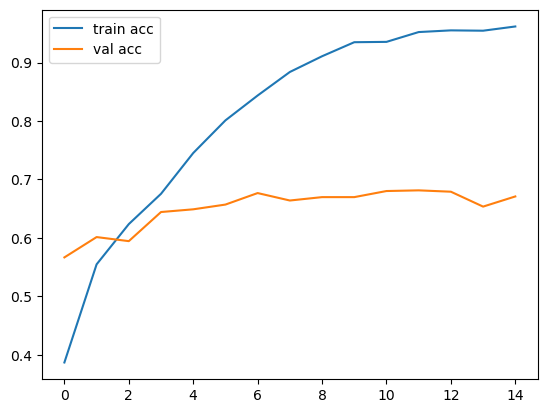

In [13]:
plt.plot(history.history["accuracy"],label = 'train acc')
plt.plot(history.history['val_accuracy'],label = 'val acc')
plt.legend()
plt.show()

In [17]:
img_path = r"C:\Deep_Learning\CNN\flowers\daisy\107592979_aaa9cdfe78_m.jpg"
img = tf.keras.utils.load_img(img_path,target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array,0) / 255.0

load_img(img_path, target_size=(224,224)) → naya image (jisko model ne kabhi nahi dekha) disk se load hota hai aur usi 224x224 size mein resize hota hai (jaisa training ke time tha)
img_to_array(img) → image ko numbers ke array mein convert karta hai (jaisa computer samajhta hai)
tf.expand_dims(img_array, 0) / 255.0 →

expand_dims(...,0) → model batch mein images expect karta hai (jaise [batch_size, 224, 224, 3]), single image ko bhi ek "batch of 1" jaisa banana padta hai
/255.0 → wahi normalization jo training data pe kiya tha, usi tarah yahan bhi zaroori hai


model.predict(img_array) ← YAHI ASLI PREDICTION LINE HAI. Model apne seekhe hue weights use karke, is image ke liye 5 numbers deta hai — jaise [0.02, 0.85, 0.05, 0.03, 0.05] — har number ek class ki probability hai.
np.argmax(predictions) → in 5 numbers mein sabse bada number kaunsa hai, uska index nikaalta hai (upar example mein index 1 hoga, kyunki 0.85 sabse zyada hai)
class_names[np.argmax(predictions)] → us index ko class_names list mein daal ke asli naam nikaalta hai — index 1 matlab "dandelion"
np.max(predictions) * 100 → confidence percentage (0.85 → 85%)

Simple shabdon mein: Model training se pehle sirf numbers samajhta hai, kuch nahi jaanta. Training (model.fit) ke baad wo pattern seekh chuka hota hai. Jab naya image model.predict() ko diya jata hai, model us image ko dekh kar batata hai "ye 85% chance hai ki ye dandelion hai" — yahi prediction ka pura process hai

In [18]:
predection = model.predict(img_array)
predicted_class = class_names[np.argmax(predection)]
confidence = np.max(predection)*100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


In [19]:
print(f"Predicted Flower: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

Predicted Flower: daisy
Confidence: 100.00%


In [16]:
model.save("flower_cnn_mmodel.keras")